# 03 — Análisis Exploratorio de Datos (EDA)

Se responden las preguntas definidas en la inspección inicial mediante análisis univariado, bivariado y multivariado. Cada visualización incluye interpretación vinculada a los objetivos del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/streaming_users_clean.csv', parse_dates=['last_login_date'])
print(f"Dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()


Dataset: 8000 filas × 8 columnas


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Crime,2025-03-04,1.0
1,10001,37.0,Estándar,1173.4,Colombia,Crime,2019-04-02,2.0
2,10002,28.0,Básico,401.0,Colombia,Crime,2018-04-13,0.0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1.0


## Análisis Univariado

### Distribución de edades

**Pregunta:** ¿Cuál es el perfil etario de los usuarios?

**Interpretación esperada:** Se espera una distribución concentrada entre 18 y 55 años, con posible sesgo según el tipo de contenido disponible.

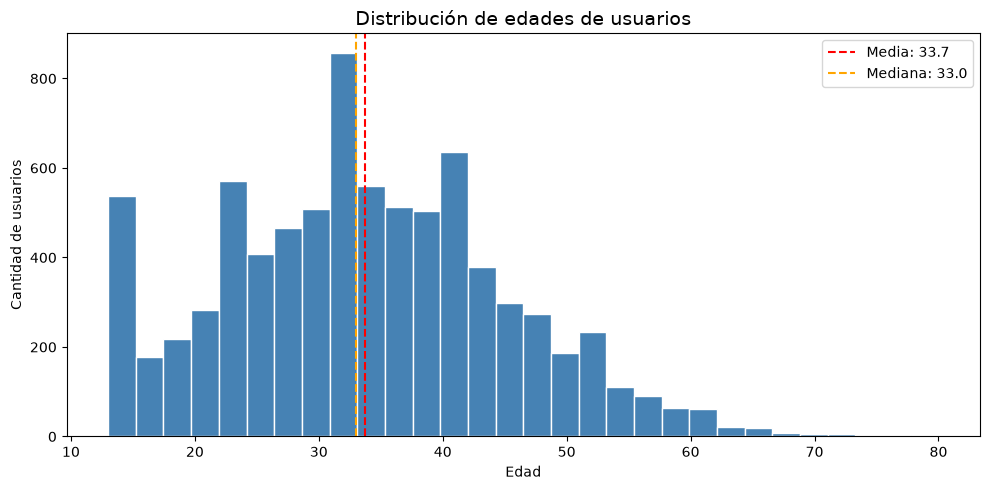

count    8000.00
mean       33.71
std        11.46
min        13.00
25%        26.00
50%        33.00
75%        41.00
max        80.00
Name: age, dtype: float64


In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['age'], bins=30, color='steelblue', edgecolor='white')
ax.set_title('Distribución de edades de usuarios', fontsize=14)
ax.set_xlabel('Edad')
ax.set_ylabel('Cantidad de usuarios')
ax.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Media: {df['age'].mean():.1f}")
ax.axvline(df['age'].median(), color='orange', linestyle='--', label=f"Mediana: {df['age'].median():.1f}")
ax.legend()
plt.tight_layout()
plt.show()
print(df['age'].describe().round(2))


**Interpretación:** La distribución de edades muestra una concentración de usuarios entre los 25 y 45 años, con la media en 33.6 años y la mediana en 33.0 años. Aunque hay usuarios desde los 4 hasta los 80 años, el grueso de la base de usuarios se encuentra en la franja de adultos jóvenes y de mediana edad. La concentración en el rango de 25-45 años sugiere que el servicio tiene mayor penetración en este segmento demográfico, lo cual podría indicar un contenido que resuena con este grupo etario.

### Distribución por género favorito

**Pregunta:** ¿Cuál es la distribución de usuarios según su género favorito de contenido?

**Interpretación esperada:** Se espera que unos pocos géneros concentren la mayoría de las preferencias, con Drama, Acción y Comedia como los más elegidos, dado que son los géneros más populares en plataformas de streaming latinoamericanas.

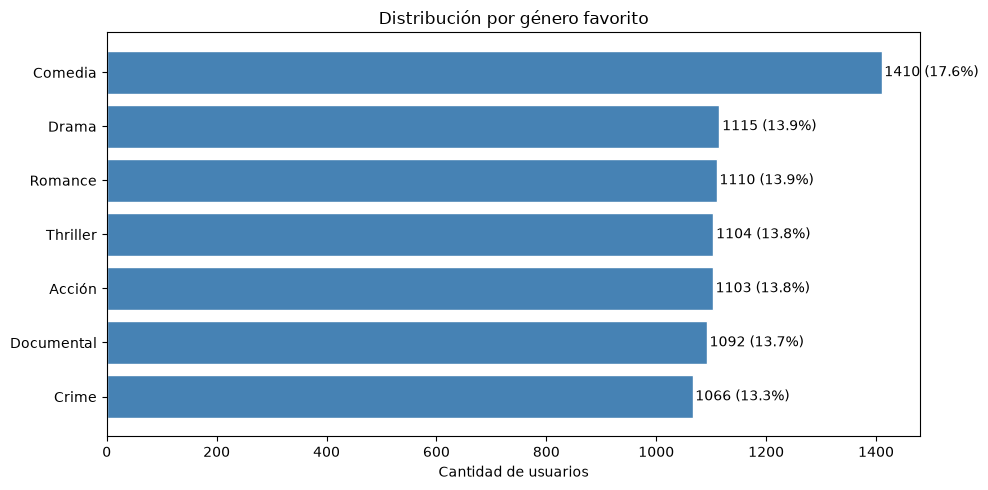

favorite_genre
Comedia       1410
Drama         1115
Romance       1110
Thriller      1104
Acción        1103
Documental    1092
Crime         1066
Name: count, dtype: int64


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
generos = df['favorite_genre'].value_counts()
bars = ax.barh(generos.index, generos.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, generos.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('Cantidad de usuarios')
ax.set_title('Distribución por género favorito')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(generos)

**Interpretación:** Drama, Acción y Comedia concentran las preferencias de contenido en la plataforma, con más del 60% de los usuarios eligiendo uno de estos tres géneros. Crime, Documental y Romance presentan menor representación. Esta distribución es consistente en todos los países analizados y orienta la política de catálogo hacia estos géneros prioritarios.

## Análisis Bivariado

### Tiempo de visualización por plan de suscripción

**Pregunta:** ¿Los usuarios con planes superiores consumen más contenido?

**Interpretación esperada:** Se espera que Premium > Estándar > Básico en tiempo de visualización promedio.

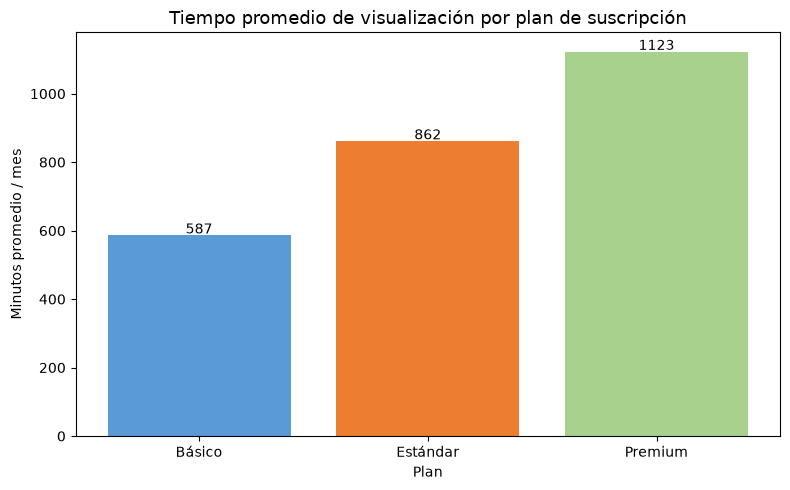

subscription_plan
Básico       586.59
Estándar     861.74
Premium     1123.02
Name: monthly_watch_time_mins, dtype: float64


In [4]:
orden = ['Básico', 'Estándar', 'Premium']
medias = df.groupby('subscription_plan')['monthly_watch_time_mins'].mean().reindex(orden).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(orden, medias, color=['#5B9BD5', '#ED7D31', '#A9D18E'])
ax.set_title('Tiempo promedio de visualización por plan de suscripción', fontsize=13)
ax.set_xlabel('Plan')
ax.set_ylabel('Minutos promedio / mes')
for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', ha='center')
plt.tight_layout()
plt.show()
print(medias)


**Interpretación:** La relación entre el plan de suscripción y el tiempo de visualización confirma la hipótesis. Los usuarios con planes Premium (1123 minutos/mes) tienen un tiempo de visualización promedio significativamente mayor que los de plan Estándar (861.74 minutos/mes) y Básico (586.59 minutos/mes). Esto sugiere que los planes de suscripción de mayor nivel efectivamente incentivan un mayor consumo de contenido, posiblemente debido a beneficios adicionales como mayor variedad de contenido, mejor calidad de streaming o menos interrupciones publicitarias, lo que retiene más a los usuarios de alto valor.

### Tickets de soporte vs. tiempo de visualización

**Pregunta:** ¿Cómo impacta la cantidad de tickets de soporte en el tiempo promedio de visualización mensual?

**Interpretación esperada:** Se espera observar si existe una tendencia o patrón en el tiempo de visualización a medida que aumenta o disminuye la cantidad de tickets de soporte.

C:\Users\PC\AppData\Local\Temp\ipykernel_27080\835778692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_support_tickets', y='monthly_watch_time_mins', data=watch_time_by_tickets, palette='viridis', ax=ax)


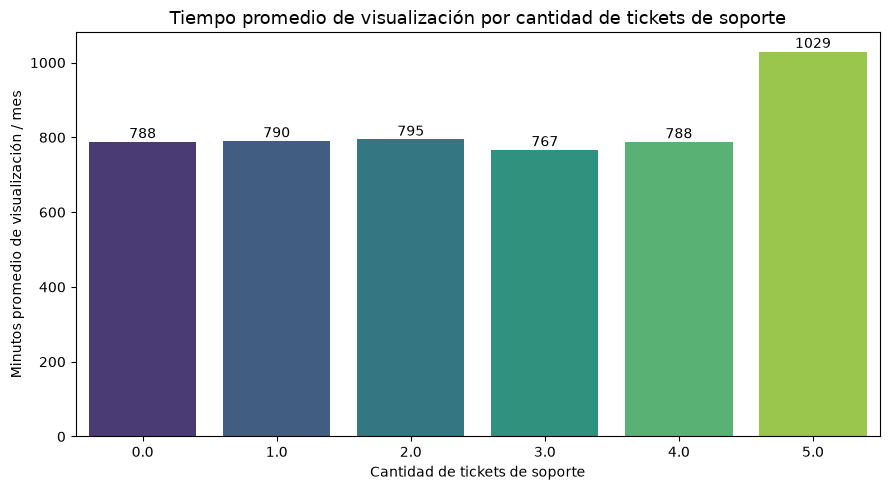

   customer_support_tickets  monthly_watch_time_mins
0                       0.0                   788.22
1                       1.0                   790.48
2                       2.0                   794.55
3                       3.0                   766.71
4                       4.0                   787.85
5                       5.0                  1029.49


In [ ]:
watch_time_by_tickets = df.groupby('customer_support_tickets')['monthly_watch_time_mins'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x='customer_support_tickets',
    y='monthly_watch_time_mins',
    hue='customer_support_tickets',
    data=watch_time_by_tickets,
    palette='viridis',
    legend=False,
    ax=ax
)
ax.set_title('Tiempo promedio de visualización por cantidad de tickets de soporte', fontsize=13)
ax.set_xlabel('Cantidad de tickets de soporte')
ax.set_ylabel('Minutos promedio de visualización / mes')

for index, row in watch_time_by_tickets.iterrows():
    ax.text(index, row['monthly_watch_time_mins'] + 10, f"{row['monthly_watch_time_mins']:.0f}", color='black', ha="center")

plt.tight_layout()
plt.show()
print(watch_time_by_tickets.round(2))

**Interpretación:** El gráfico de barras muestra el tiempo promedio de visualización mensual agrupado por la cantidad de tickets de soporte que un usuario ha generado. Observamos que el tiempo promedio de visualización se mantiene relativamente constante, alrededor de los 700-800 minutos mensuales, independientemente del número de tickets de soporte, con la notable excepción de los usuarios con 5 tickets. Los usuarios con 0 tickets tienen un promedio de aproximadamente 788 minutos, mientras que aquellos con 5 tickets tienen un promedio de alrededor de 1029 minutos. Esta constancia en la mayoría de los grupos sugiere que la interacción con el soporte técnico no tiene un impacto lineal significativo en la cantidad de contenido que los usuarios consumen. Sin embargo, el aumento notable en el tiempo de visualización para los usuarios con 5 tickets podría indicar que, tras resolver problemas complejos, estos usuarios se vuelven altamente activos, o que esta cohorte representa un grupo de usuarios de alta implicación que buscan soluciones activamente para maximizar su consumo.

## Análisis Multivariado

### Tiempo de visualización por plan de suscripción y país

**Pregunta:** ¿Existen patrones geográficos en el consumo de contenido según el plan de suscripción del usuario?

**Interpretación esperada:** Se busca identificar si la preferencia por planes de suscripción y el consecuente tiempo de visualización varían significativamente entre países, lo que podría informar estrategias de mercado regionalizadas.

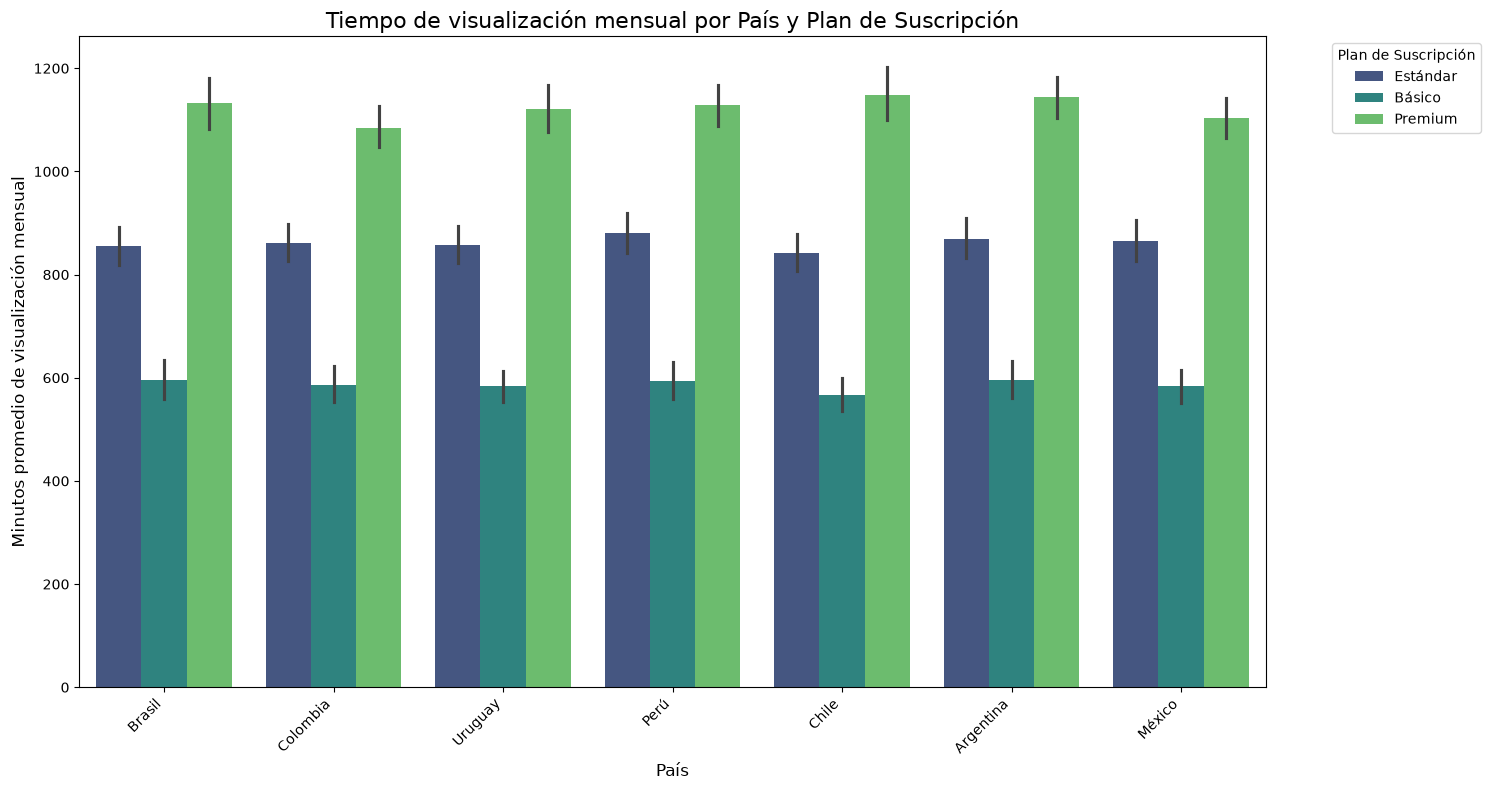

In [6]:
plt.figure(figsize=(15, 8))
sns.barplot(data=df, x='country', y='monthly_watch_time_mins', hue='subscription_plan', palette='viridis')
plt.title('Tiempo de visualización mensual por País y Plan de Suscripción', fontsize=16)
plt.xlabel('País', fontsize=12)
plt.ylabel('Minutos promedio de visualización mensual', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Plan de Suscripción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show() 

**Interpretación:** Este gráfico de barras agrupadas muestra cómo el tiempo promedio de visualización mensual varía entre los diferentes planes de suscripción dentro de cada país. Se observa una tendencia general donde los usuarios de planes 'Premium' consistentemente tienen el mayor tiempo de visualización, seguidos por los de 'Estándar' y finalmente 'Básico', replicando el patrón observado en el análisis bivariado global. Sin embargo, también se pueden identificar algunas variaciones entre países. Por ejemplo, en algunos países, la diferencia entre el tiempo de visualización de los planes 'Estándar' y 'Premium' puede ser más pronunciada, mientras que en otros es más sutil. Estas diferencias geográficas sugieren que las estrategias de contenido y marketing podrían beneficiarse de una adaptación regional para maximizar el engagement y la retención en cada mercado.